# Análisis geométrico de nubes de puntos COLMAP

Este notebook analiza outputs geométricos del pipeline fotogramétrico, principalmente nubes `.ply` generadas por COLMAP / Stereo Fusion y nubes limpias exportadas desde CloudCompare.

A diferencia del benchmark de renders, este análisis evalúa:

- cantidad de puntos;
- bounding box;
- centroide;
- densidad aproximada;
- distancia a vecinos cercanos;
- distribución espacial;
- comparación entre nube cruda y nube limpia;
- reducción de puntos por limpieza;
- reporte PDF final.

Estructura recomendada en Drive:

```text
PROJECT_DIR/
  pointclouds/
    fused_medium.ply
    fused_medium_high.ply
    fused_medium_high_clean.ply
  pointcloud-outputs/
```

Todos los resultados se guardan en:

```text
PROJECT_DIR/pointcloud-outputs
```

In [1]:
# ============================================================
# 0. Instalar dependencias
# ============================================================

!pip -q install open3d pandas numpy matplotlib reportlab

import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import open3d as o3d

from pathlib import Path
from datetime import datetime

print("Dependencias listas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.3 MB/s eta 0:00:00
Dependencias listas.


## 1. Montar Google Drive y definir rutas

Ajustá `PROJECT_DIR` para que apunte al root real de tu proyecto.

El notebook buscará nubes `.ply` en:

```text
PROJECT_DIR/pointclouds
```

También podés apuntar `POINTCLOUDS_DIR` a otra carpeta si querés analizar archivos que estén en `colmap_dense_clean`.

In [2]:
# ============================================================
# 1. Montar Google Drive y definir rutas
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# Ajustar a tu root real en Drive
PROJECT_DIR = Path("/content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks")

# Carpeta de entrada de nubes de puntos
POINTCLOUDS_DIR = PROJECT_DIR / "pointclouds"

# Carpeta de salida
OUTPUT_DIR = PROJECT_DIR / "pointcloud-outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("POINTCLOUDS_DIR:", POINTCLOUDS_DIR, "| exists:", POINTCLOUDS_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

# Si tus PLY están en otra carpeta, editá por ejemplo:
# POINTCLOUDS_DIR = PROJECT_DIR / "colmap_dense_clean"

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks
POINTCLOUDS_DIR: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointclouds | exists: True
OUTPUT_DIR: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs


In [3]:
# ============================================================
# 1B. Indexar archivos PLY
# ============================================================

assert POINTCLOUDS_DIR.exists(), f"No existe POINTCLOUDS_DIR: {POINTCLOUDS_DIR}"

ply_files = sorted(POINTCLOUDS_DIR.rglob("*.ply"))

ply_index = pd.DataFrame({
    "ply_name": [p.name for p in ply_files],
    "path": [str(p) for p in ply_files],
    "size_mb": [round(p.stat().st_size / (1024 * 1024), 2) for p in ply_files],
})

ply_index.to_csv(OUTPUT_DIR / "pointclouds_index.csv", index=False)

print("PLY encontrados:", len(ply_files))
ply_index

PLY encontrados: 4


,ply_name,path,size_mb
0,fused_low.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,21.38
1,fused_medium.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,40.92
2,fused_medium_high.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,54.26
3,fused_medium_high_clean.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,12.95


## 2. Cargar nubes y calcular métricas globales

Métricas calculadas:

- cantidad de puntos;
- presencia de color;
- presencia de normales;
- bounding box;
- centroide;
- extensión espacial;
- densidad aproximada por volumen de bounding box.

> La densidad es aproximada porque usa el volumen de la caja envolvente, no el volumen real de la geometría.

In [4]:
# ============================================================
# 2. Cargar nubes y métricas globales
# ============================================================

def load_point_cloud(path):
    pcd = o3d.io.read_point_cloud(str(path))
    return pcd

def pointcloud_metrics(path):
    pcd = load_point_cloud(path)
    pts = np.asarray(pcd.points)

    if len(pts) == 0:
        return {
            "ply_name": Path(path).name,
            "path": str(path),
            "points": 0,
            "has_colors": False,
            "has_normals": False,
        }, pcd

    bbox_min = pts.min(axis=0)
    bbox_max = pts.max(axis=0)
    bbox_size = bbox_max - bbox_min
    centroid = pts.mean(axis=0)
    bbox_volume = float(np.prod(bbox_size)) if np.all(bbox_size > 0) else np.nan

    metrics = {
        "ply_name": Path(path).name,
        "path": str(path),
        "file_size_mb": round(Path(path).stat().st_size / (1024 * 1024), 2),
        "points": int(len(pts)),
        "has_colors": bool(pcd.has_colors()),
        "has_normals": bool(pcd.has_normals()),
        "bbox_min_x": bbox_min[0],
        "bbox_min_y": bbox_min[1],
        "bbox_min_z": bbox_min[2],
        "bbox_max_x": bbox_max[0],
        "bbox_max_y": bbox_max[1],
        "bbox_max_z": bbox_max[2],
        "bbox_size_x": bbox_size[0],
        "bbox_size_y": bbox_size[1],
        "bbox_size_z": bbox_size[2],
        "bbox_volume_dataset_units": bbox_volume,
        "centroid_x": centroid[0],
        "centroid_y": centroid[1],
        "centroid_z": centroid[2],
        "approx_points_per_bbox_volume": len(pts) / bbox_volume if bbox_volume and bbox_volume > 0 else np.nan,
    }

    return metrics, pcd

pcd_cache = {}
metrics_rows = []

for p in ply_files:
    metrics, pcd = pointcloud_metrics(p)
    metrics_rows.append(metrics)
    pcd_cache[p.name] = pcd

pc_metrics_df = pd.DataFrame(metrics_rows)
pc_metrics_df.to_csv(OUTPUT_DIR / "pointcloud_global_metrics.csv", index=False)

pc_metrics_df

,ply_name,path,file_size_mb,points,has_colors,has_normals,bbox_min_x,bbox_min_y,bbox_min_z,bbox_max_x,bbox_max_y,bbox_max_z,bbox_size_x,bbox_size_y,bbox_size_z,bbox_volume_dataset_units,centroid_x,centroid_y,centroid_z,approx_points_per_bbox_volume
0,fused_low.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,21.38,830361,True,True,-409.850006,-60.945557,-310.387512,388.289948,6.590439,371.013336,798.139954,67.535995,681.400848,3.672967e+07,-0.532119,2.110500,-1.303597,0.022607
1,fused_medium.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,40.92,1589360,True,True,-933.196960,-151.802902,-921.201294,979.916870,164.969193,621.635132,1913.113831,316.772095,1542.836426,9.349914e+08,-0.295668,1.820614,0.277877,0.001700
2,fused_medium_high.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,54.26,2107280,True,True,-983.153992,-337.194244,-910.712402,1265.641968,171.588776,1751.044800,2248.795959,508.783020,2661.757202,3.045447e+09,-0.552598,1.662478,0.490911,0.000692
3,fused_medium_high_clean.ply,/content/drive/MyDrive/Tesis: Tecnicas de CV p...,12.95,502817,True,True,-3.198848,-0.565113,-4.473100,4.564765,2.693826,2.260649,7.763613,3.258939,6.733749,1.703715e+02,0.552209,1.061111,-1.171558,2951.297067


## 3. Muestreo para análisis eficiente

Las nubes pueden tener millones de puntos. Para métricas de vecinos cercanos y gráficos, se usa un muestreo aleatorio reproducible.

In [5]:
# ============================================================
# 3. Muestreo
# ============================================================

RANDOM_SEED = 42
MAX_SAMPLE_POINTS = 150_000
NN_SAMPLE_POINTS = 50_000

rng = np.random.default_rng(RANDOM_SEED)

def sample_points(points, max_points):
    n = len(points)
    if n <= max_points:
        return points
    idx = rng.choice(n, size=max_points, replace=False)
    return points[idx]

sampled_points = {}

for name, pcd in pcd_cache.items():
    pts = np.asarray(pcd.points)
    sampled_points[name] = sample_points(pts, MAX_SAMPLE_POINTS)
    print(name, "original:", len(pts), "sample:", len(sampled_points[name]))

fused_low.ply original: 830361 sample: 150000
fused_medium.ply original: 1589360 sample: 150000
fused_medium_high.ply original: 2107280 sample: 150000
fused_medium_high_clean.ply original: 502817 sample: 150000


## 4. Distancia a vecinos cercanos

Esta métrica aproxima la densidad local de la nube.

- Distancia media baja: puntos más densos.
- Distancia alta o cola larga: zonas dispersas / ruido / bordes / baja cobertura.

Se calcula sobre una muestra para evitar costos excesivos.

In [6]:
# ============================================================
# 4. Nearest neighbor distance
# ============================================================

nn_rows = []

for name, pcd in pcd_cache.items():
    pts = np.asarray(pcd.points)
    if len(pts) == 0:
        continue

    pts_nn = sample_points(pts, NN_SAMPLE_POINTS)

    temp_pcd = o3d.geometry.PointCloud()
    temp_pcd.points = o3d.utility.Vector3dVector(pts_nn)

    distances = np.asarray(temp_pcd.compute_nearest_neighbor_distance())

    np.save(OUTPUT_DIR / f"nn_distances_{Path(name).stem}.npy", distances)

    nn_rows.append({
        "ply_name": name,
        "nn_sample_points": len(pts_nn),
        "nn_mean": float(np.mean(distances)),
        "nn_median": float(np.median(distances)),
        "nn_std": float(np.std(distances)),
        "nn_min": float(np.min(distances)),
        "nn_p05": float(np.percentile(distances, 5)),
        "nn_p25": float(np.percentile(distances, 25)),
        "nn_p75": float(np.percentile(distances, 75)),
        "nn_p95": float(np.percentile(distances, 95)),
        "nn_max": float(np.max(distances)),
    })

nn_metrics_df = pd.DataFrame(nn_rows)
nn_metrics_df.to_csv(OUTPUT_DIR / "pointcloud_nearest_neighbor_metrics.csv", index=False)

nn_metrics_df

,ply_name,nn_sample_points,nn_mean,nn_median,nn_std,nn_min,nn_p05,nn_p25,nn_p75,nn_p95,nn_max
0,fused_low.ply,50000,0.121171,0.037547,0.957214,0.000735,0.009396,0.021707,0.071415,0.320550,145.928352
1,fused_medium.ply,50000,0.226684,0.047319,1.768204,0.001046,0.009999,0.024260,0.109312,0.700250,201.505025
2,fused_medium_high.ply,50000,0.317050,0.053405,3.342904,0.000556,0.010482,0.026097,0.133145,1.004902,494.024036
3,fused_medium_high_clean.ply,50000,0.014363,0.011974,0.011588,0.000301,0.003666,0.007670,0.018084,0.031916,0.644783


## 5. Comparación cruda vs limpia

Si el notebook encuentra nombres típicos como:

```text
fused_medium_high.ply
fused_medium_high_clean.ply
```

calcula la reducción porcentual de puntos y tamaño.

In [7]:
# ============================================================
# 5. Comparación cruda vs limpia
# ============================================================

def find_by_contains(df, contains):
    sub = df[df["ply_name"].str.contains(contains, case=False, regex=False)]
    if len(sub) == 0:
        return None
    return sub.iloc[0]

comparison_rows = []

# Comparaciones automáticas por nombres comunes
possible_pairs = [
    ("fused_medium_high.ply", "fused_medium_high_clean.ply"),
    ("fused_medium.ply", "fused_medium_high_clean.ply"),
]

for raw_name, clean_name in possible_pairs:
    raw = pc_metrics_df[pc_metrics_df["ply_name"] == raw_name]
    clean = pc_metrics_df[pc_metrics_df["ply_name"] == clean_name]

    if len(raw) > 0 and len(clean) > 0:
        raw = raw.iloc[0]
        clean = clean.iloc[0]
        comparison_rows.append({
            "raw_cloud": raw_name,
            "clean_cloud": clean_name,
            "raw_points": raw["points"],
            "clean_points": clean["points"],
            "points_removed": raw["points"] - clean["points"],
            "points_retained_pct": 100 * clean["points"] / raw["points"] if raw["points"] else np.nan,
            "raw_size_mb": raw["file_size_mb"],
            "clean_size_mb": clean["file_size_mb"],
            "size_retained_pct": 100 * clean["file_size_mb"] / raw["file_size_mb"] if raw["file_size_mb"] else np.nan,
        })

cleaning_comparison_df = pd.DataFrame(comparison_rows)
cleaning_comparison_df.to_csv(OUTPUT_DIR / "pointcloud_cleaning_comparison.csv", index=False)

if len(cleaning_comparison_df) == 0:
    print("No se detectaron pares cruda/limpia por nombre. Podés editar possible_pairs en la celda.")
else:
    display(cleaning_comparison_df)

,raw_cloud,clean_cloud,raw_points,clean_points,points_removed,points_retained_pct,raw_size_mb,clean_size_mb,size_retained_pct
0,fused_medium_high.ply,fused_medium_high_clean.ply,2107280,502817,1604463,23.860949,54.26,12.95,23.866568
1,fused_medium.ply,fused_medium_high_clean.ply,1589360,502817,1086543,31.636445,40.92,12.95,31.647116


## 6. Gráficos

Se generan gráficos de:

- cantidad de puntos por nube;
- tamaño de archivo;
- bounding box;
- distribución de vecinos cercanos;
- proyecciones 2D.

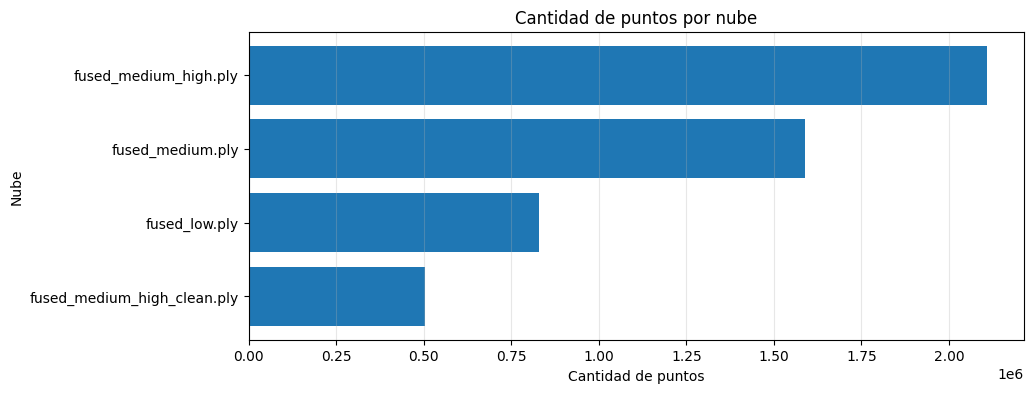

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/pointcloud_points_count.png


In [8]:
# ============================================================
# 6A. Cantidad de puntos
# ============================================================

plot_df = pc_metrics_df.sort_values("points", ascending=True)

plt.figure(figsize=(10, max(4, 0.4 * len(plot_df))))
plt.barh(plot_df["ply_name"], plot_df["points"])
plt.xlabel("Cantidad de puntos")
plt.ylabel("Nube")
plt.title("Cantidad de puntos por nube")
plt.grid(True, axis="x", alpha=0.3)
out = OUTPUT_DIR / "pointcloud_points_count.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

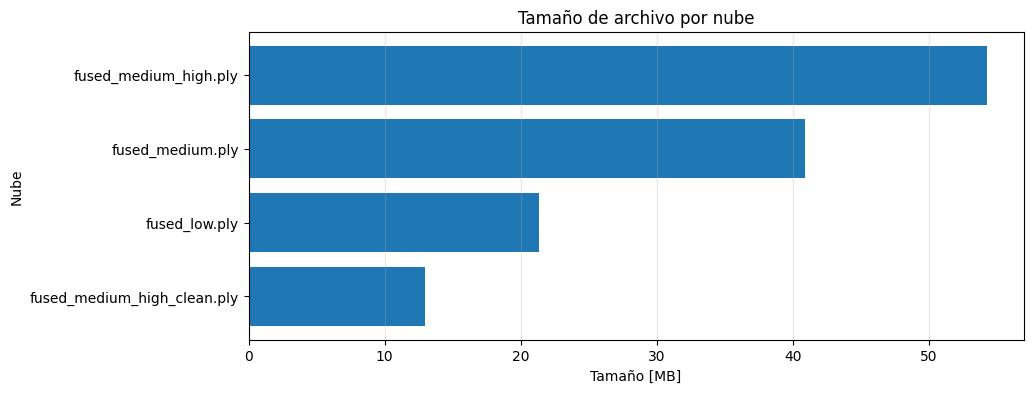

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/pointcloud_file_size.png


In [9]:
# ============================================================
# 6B. Tamaño de archivos
# ============================================================

plot_df = pc_metrics_df.sort_values("file_size_mb", ascending=True)

plt.figure(figsize=(10, max(4, 0.4 * len(plot_df))))
plt.barh(plot_df["ply_name"], plot_df["file_size_mb"])
plt.xlabel("Tamaño [MB]")
plt.ylabel("Nube")
plt.title("Tamaño de archivo por nube")
plt.grid(True, axis="x", alpha=0.3)
out = OUTPUT_DIR / "pointcloud_file_size.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

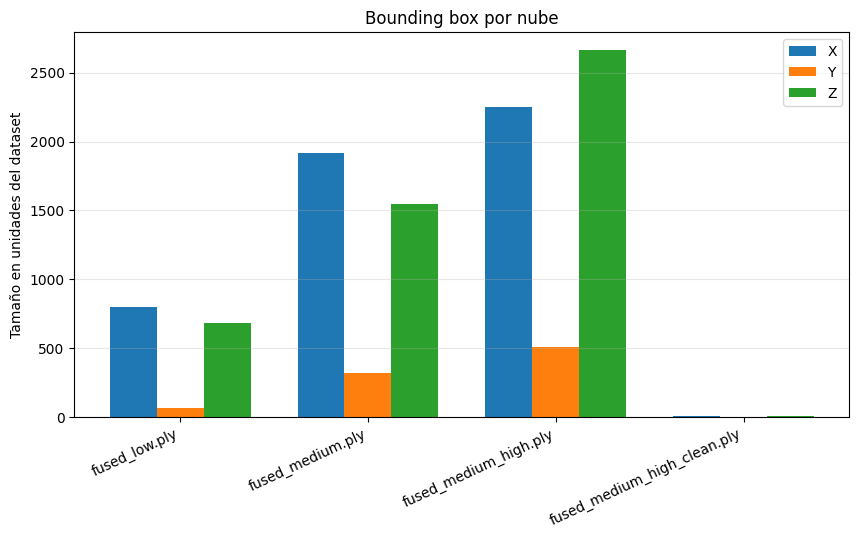

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/pointcloud_bbox_sizes.png


In [10]:
# ============================================================
# 6C. Bounding box por eje
# ============================================================

bbox_cols = ["bbox_size_x", "bbox_size_y", "bbox_size_z"]
bbox_df = pc_metrics_df[["ply_name"] + bbox_cols].copy()
bbox_df = bbox_df.set_index("ply_name")

plt.figure(figsize=(10, 5))
x = np.arange(len(bbox_df))
width = 0.25

plt.bar(x - width, bbox_df["bbox_size_x"], width, label="X")
plt.bar(x, bbox_df["bbox_size_y"], width, label="Y")
plt.bar(x + width, bbox_df["bbox_size_z"], width, label="Z")

plt.xticks(x, bbox_df.index, rotation=25, ha="right")
plt.ylabel("Tamaño en unidades del dataset")
plt.title("Bounding box por nube")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
out = OUTPUT_DIR / "pointcloud_bbox_sizes.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print("Guardado:", out)

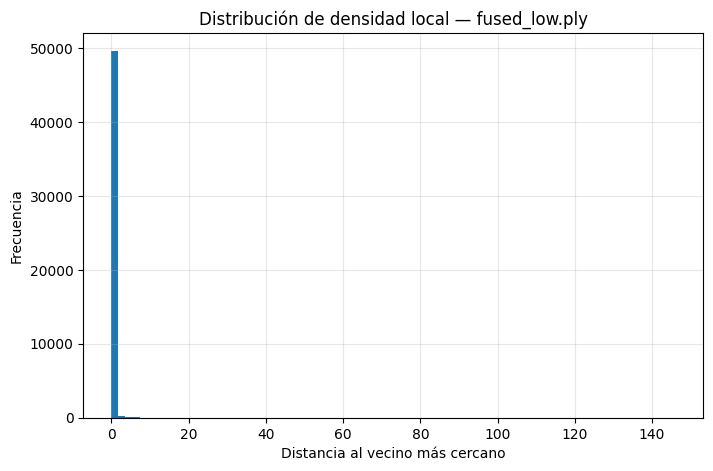

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/nn_histogram_fused_low.png


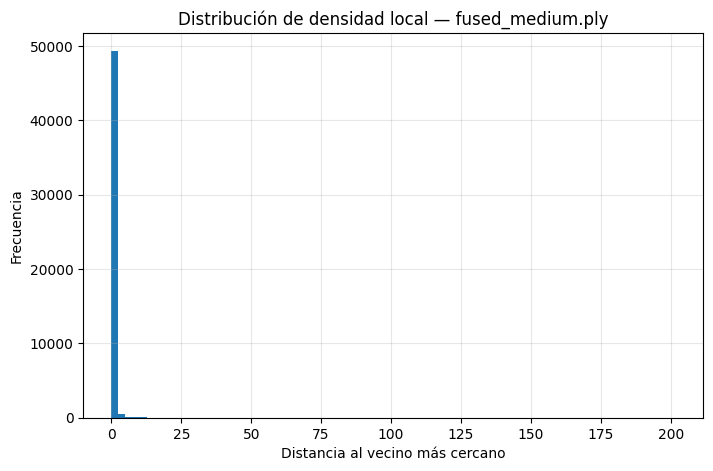

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/nn_histogram_fused_medium.png


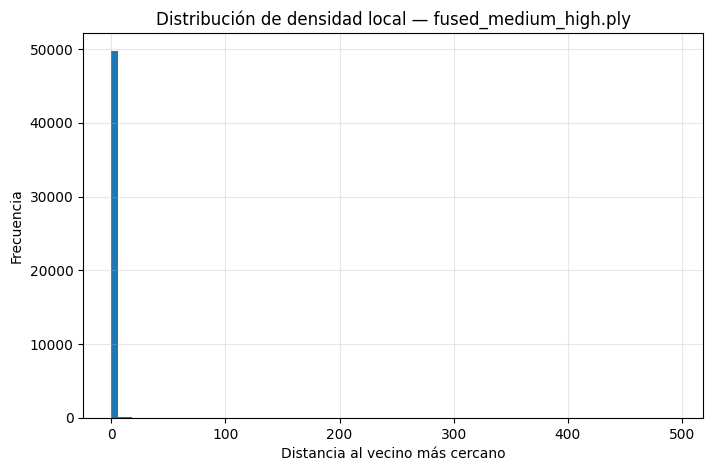

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/nn_histogram_fused_medium_high.png


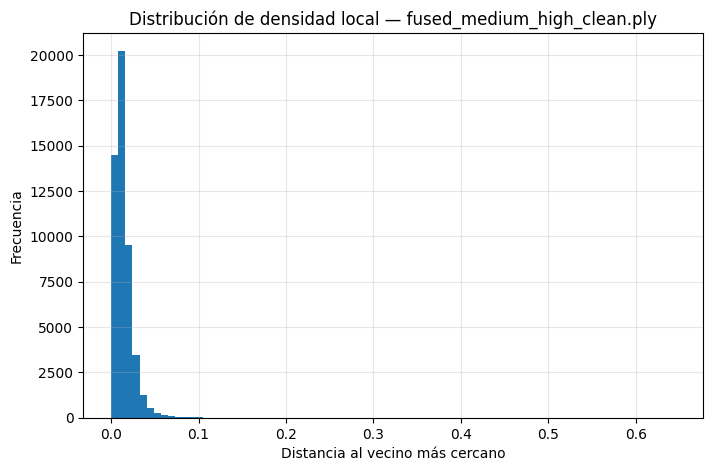

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/nn_histogram_fused_medium_high_clean.png


In [11]:
# ============================================================
# 6D. Histogramas de distancia a vecino cercano
# ============================================================

for name in nn_metrics_df["ply_name"]:
    npy_path = OUTPUT_DIR / f"nn_distances_{Path(name).stem}.npy"
    if not npy_path.exists():
        continue

    distances = np.load(npy_path)

    plt.figure(figsize=(8, 5))
    plt.hist(distances, bins=80)
    plt.xlabel("Distancia al vecino más cercano")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de densidad local — {name}")
    plt.grid(True, alpha=0.3)
    out = OUTPUT_DIR / f"nn_histogram_{Path(name).stem}.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

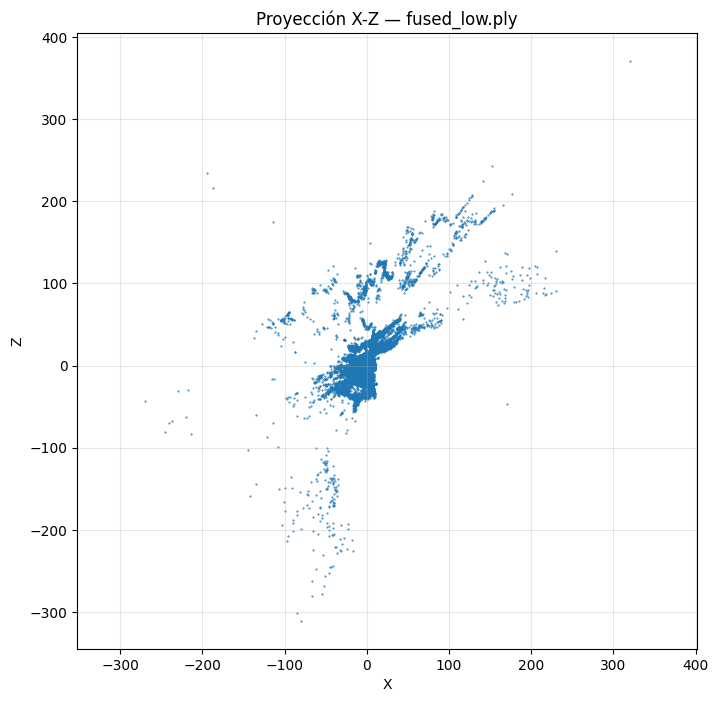

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/projection_xz_fused_low.png


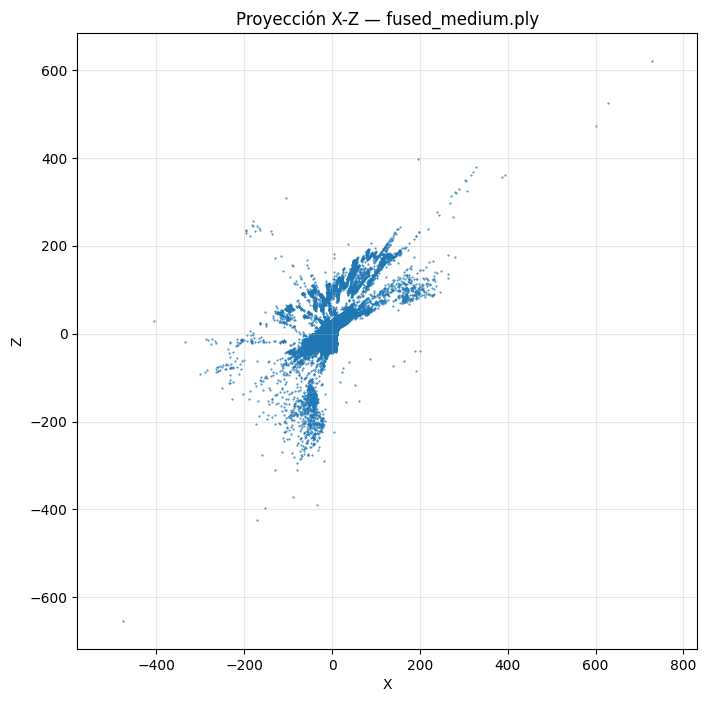

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/projection_xz_fused_medium.png


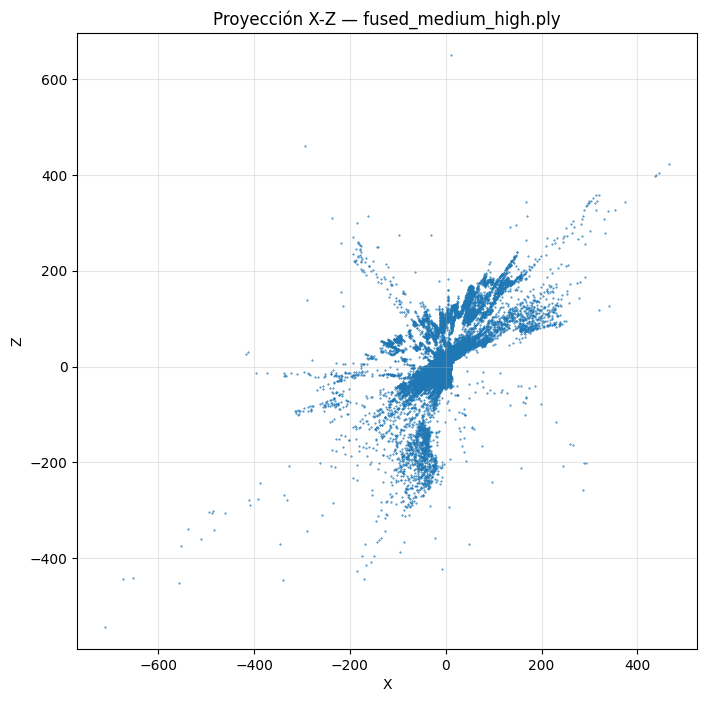

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/projection_xz_fused_medium_high.png


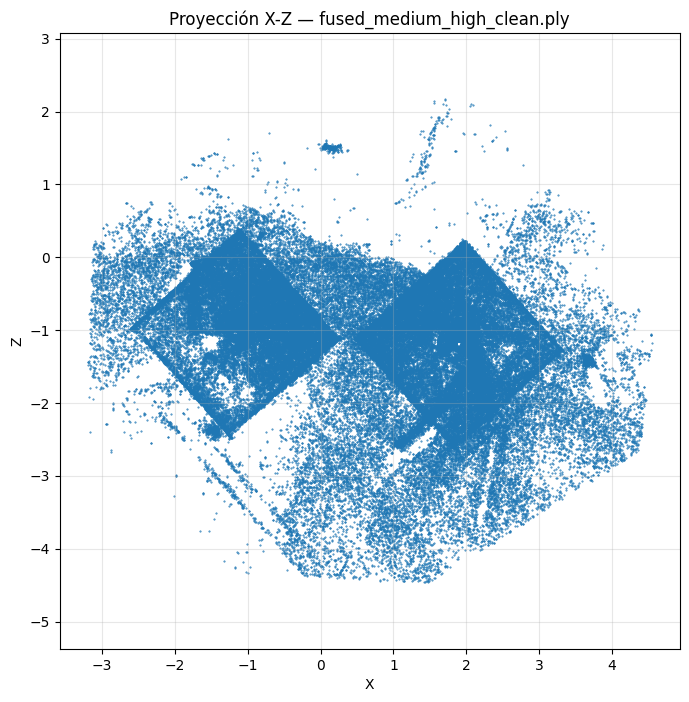

Guardado: /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/projection_xz_fused_medium_high_clean.png


In [12]:
# ============================================================
# 6E. Proyecciones 2D X-Z
# ============================================================

for name, pts in sampled_points.items():
    if len(pts) == 0:
        continue

    plt.figure(figsize=(8, 8))
    plt.scatter(pts[:, 0], pts[:, 2], s=0.2)
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.title(f"Proyección X-Z — {name}")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    out = OUTPUT_DIR / f"projection_xz_{Path(name).stem}.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Guardado:", out)

## 7. Reporte PDF

In [15]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage, PageBreak

PDF_PATH = OUTPUT_DIR / "pointcloud_analysis_report.pdf"

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="TitleCenterCustom", parent=styles["Title"], alignment=TA_CENTER, fontSize=18, leading=22, spaceAfter=16))
styles.add(ParagraphStyle(name="SectionTitleCustom", parent=styles["Heading1"], fontSize=14, leading=17, spaceBefore=10, spaceAfter=8))
styles.add(ParagraphStyle(name="BodySmallCustom", parent=styles["BodyText"], fontSize=9, leading=12, spaceAfter=6))
styles.add(ParagraphStyle(name="TableCellCustom", parent=styles["BodyText"], fontSize=6, leading=7))

def clean_text_pdf(value):
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")

def make_table_pdf(df, font_size=6, max_rows=None, col_widths=None):
    d = df.copy()
    if max_rows is not None:
        d = d.head(max_rows)
    for col in d.columns:
        if pd.api.types.is_float_dtype(d[col]):
            d[col] = d[col].round(4)
    raw = [list(d.columns)] + d.astype(str).values.tolist()
    data = [[Paragraph(clean_text_pdf(cell), styles["TableCellCustom"]) for cell in row] for row in raw]

    if col_widths is None:
        page_width = landscape(A4)[0] - 3 * cm
        n_cols = max(len(d.columns), 1)
        col_widths = [page_width / n_cols] * n_cols

    table = Table(data, repeatRows=1, colWidths=col_widths)
    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, -1), font_size),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.whitesmoke]),
    ]))
    return table

def image_for_pdf(path, max_width=26*cm, max_height=14*cm):
    path = Path(path)
    if not path.exists():
        return None
    img = RLImage(str(path))
    iw, ih = img.imageWidth, img.imageHeight
    if iw == 0 or ih == 0:
        return None
    scale = min(max_width / iw, max_height / ih)
    img.drawWidth = iw * scale
    img.drawHeight = ih * scale
    return img

doc = SimpleDocTemplate(
    str(PDF_PATH),
    pagesize=landscape(A4),
    rightMargin=1.5*cm,
    leftMargin=1.5*cm,
    topMargin=1.5*cm,
    bottomMargin=1.5*cm,
)

story = []

story.append(Paragraph("Análisis geométrico de nubes de puntos", styles["TitleCenterCustom"]))
story.append(Paragraph("COLMAP / Stereo Fusion / CloudCompare", styles["BodySmallCustom"]))
story.append(Spacer(1, 0.4*cm))

story.append(Paragraph("1. Objetivo", styles["SectionTitleCustom"]))
story.append(Paragraph(
    "Este reporte analiza los outputs geométricos del pipeline fotogramétrico. "
    "A diferencia del benchmark de renders, este análisis se centra en propiedades de la nube de puntos: cantidad de puntos, "
    "extensión espacial, densidad aproximada y efecto de la limpieza.",
    styles["BodySmallCustom"]
))

story.append(Paragraph("2. Índice de archivos PLY", styles["SectionTitleCustom"]))
story.append(make_table_pdf(ply_index, font_size=5, max_rows=30, col_widths=[8*cm, 16*cm, 3*cm]))

story.append(PageBreak())

story.append(Paragraph("3. Métricas globales", styles["SectionTitleCustom"]))
metric_cols = [
    "ply_name", "file_size_mb", "points", "has_colors", "has_normals",
    "bbox_size_x", "bbox_size_y", "bbox_size_z", "approx_points_per_bbox_volume"
]
metric_cols = [c for c in metric_cols if c in pc_metrics_df.columns]
story.append(make_table_pdf(pc_metrics_df[metric_cols], font_size=5, col_widths=[7*cm, 3*cm, 4*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 5*cm]))

story.append(Paragraph("4. Vecinos cercanos", styles["SectionTitleCustom"]))
story.append(make_table_pdf(nn_metrics_df, font_size=5, col_widths=[7*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm, 3*cm]))

if len(cleaning_comparison_df) > 0:
    story.append(Paragraph("5. Comparación cruda vs limpia", styles["SectionTitleCustom"]))
    story.append(make_table_pdf(cleaning_comparison_df, font_size=5))

story.append(PageBreak())

story.append(Paragraph("6. Gráficos principales", styles["SectionTitleCustom"]))

for title, filename in [
    ("Cantidad de puntos", "pointcloud_points_count.png"),
    ("Tamaño de archivos", "pointcloud_file_size.png"),
    ("Bounding box", "pointcloud_bbox_sizes.png"),
]:
    img = image_for_pdf(OUTPUT_DIR / filename)
    if img is not None:
        story.append(Paragraph(title, styles["BodySmallCustom"]))
        story.append(img)
        story.append(Spacer(1, 0.3*cm))

story.append(PageBreak())

story.append(Paragraph("7. Histogramas de densidad local y proyecciones", styles["SectionTitleCustom"]))

extra_images = sorted(list(OUTPUT_DIR.glob("nn_histogram_*.png")) + list(OUTPUT_DIR.glob("projection_xz_*.png")))

for img_path in extra_images[:12]:
    img = image_for_pdf(img_path)
    if img is not None:
        story.append(Paragraph(img_path.name, styles["BodySmallCustom"]))
        story.append(img)
        story.append(Spacer(1, 0.25*cm))

story.append(PageBreak())

story.append(Paragraph("8. Conclusión metodológica", styles["SectionTitleCustom"]))
story.append(Paragraph(
    "El análisis de nubes de puntos permite evaluar la dimensión geométrica del pipeline, complementando las métricas visuales "
    "de Nerfacto y Splatfacto. La nube densa y su versión limpia pueden ser interpretadas como el output más útil para procesos "
    "de lectura geométrica, medición, limpieza manual y modelado BIM/OpenBIM posterior.",
    styles["BodySmallCustom"]
))

doc.build(story)

print("PDF generado:")
print(" -", PDF_PATH)


PDF generado:
 - /content/drive/MyDrive/Tesis: Tecnicas de CV para Reconstruccion Arquitectonica/notebooks/pointcloud-outputs/pointcloud_analysis_report.pdf


## 8. Exportar ZIP

In [ ]:
# ============================================================
# 8. Exportar ZIP
# ============================================================

zip_path = PROJECT_DIR / "pointcloud-outputs.zip"

if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("ZIP generado:", zip_path)

from google.colab import files
files.download(str(zip_path))

## 9. Texto metodológico para tesis

```text
El análisis geométrico de nubes de puntos permitió caracterizar los outputs fotogramétricos más allá de su apariencia visual. Se evaluaron cantidad de puntos, tamaño de archivo, extensión espacial, densidad aproximada y distribución de distancia a vecinos cercanos. Esta información permite justificar el uso de la nube de puntos limpia como referencia geométrica principal para etapas posteriores de interpretación arquitectónica y modelado BIM/OpenBIM.
```